# Loading fragments and making unimodal embedding

If you have unimodal data from one experiment, you can use this notebook to load the fragments.

In [1]:
import matplotlib.pyplot as plt
import sys
import numpy as np
import anndata as ad
import pandas as pd

sys.path.insert(0, '..')
import src as scit 

In [5]:
# Load genome sizes dictionary
d=scit.tl.get_genome_dict('GRCm39')

In [ ]:
adata = scit.ld.fragments(
    "private/data/marek/GSE198467_ATAC_fragments.tsv",
    ignore_missing_chr=True,
    genome_dict=d
)

In [ ]:
# Move recently loaded X into layer called 'ATAC'
scit.tl.X_to_layer(adata, 'ATAC')
scit.tl.add_metadata(adata)

In [ ]:
scit.pl.features_counts_histogram(adata)

In [ ]:
scit.pl.cells_counts_histogram(adata, log_scale=True)

In [3]:
# Filter counts
adata = scit.tl.filter(
    adata, ['ATAC'], 
    min_obs_counts=[100], 
    min_var_counts=[5],
    max_obs_counts=[99.95j], 
    return_purged=True
)

Info: The 99.95th percentile of obs total counts is 40224.71200000029


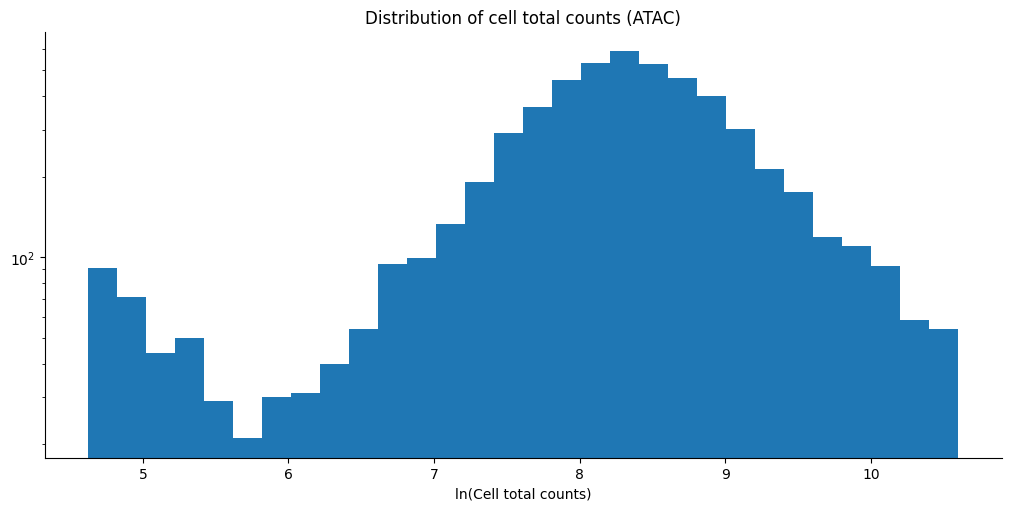

In [6]:
scit.tl.add_metadata(adata)
scit.pl.cells_counts_histogram(adata, log_scale=True)

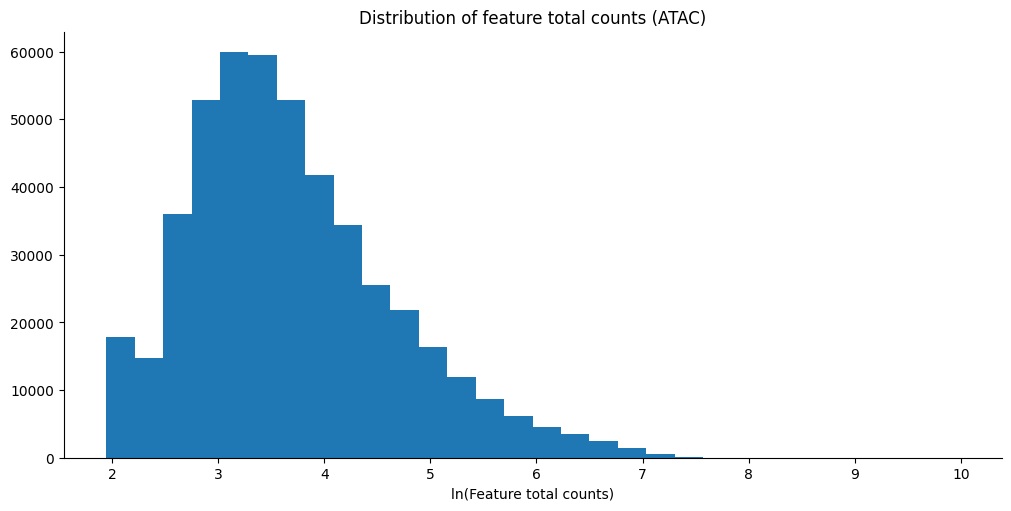

In [7]:
scit.pl.features_counts_histogram(adata)

In [10]:
# Spectral embedding
ev = scit.em.spectral(adata, 'ATAC')
print("Eigenvalues:", ev)

Eigenvalues: [1.         0.12314748 0.08594082 0.06632745 0.06398128 0.02421102
 0.01491906 0.01091844 0.00958567 0.00896558 0.00781184 0.00738134
 0.0072017  0.00656598 0.00643864 0.00632312 0.00625029 0.00618469
 0.00610824 0.00605866 0.0060287  0.         0.         0.
 0.        ]


/home/aleksander/Skrivbord/pyproject/notebooks/../src/plotting/_statistics.py:65: ConstantInputWarning: An input array is constant; the correlation coefficient is not defined.
  pers.append(sts.pearsonr(adata.obs[f'{layer}_total_counts'], arr))


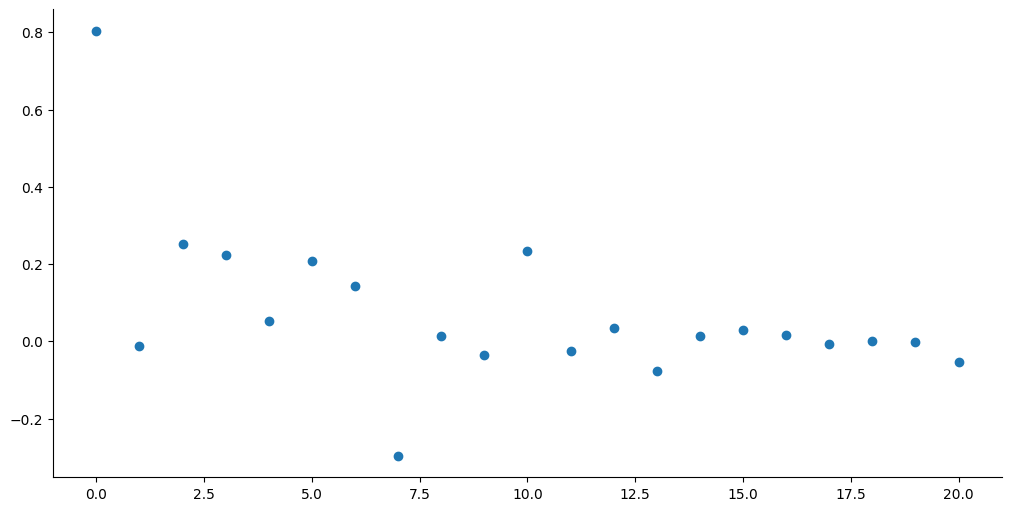

In [11]:
# Visualize depth correlation, in order to remove highly correlating first PC
scit.pl.depth_corr(adata, 'X_spectral', 'ATAC')

In [12]:
scit.tl.remove_pc(adata, 'X_spectral', 0)

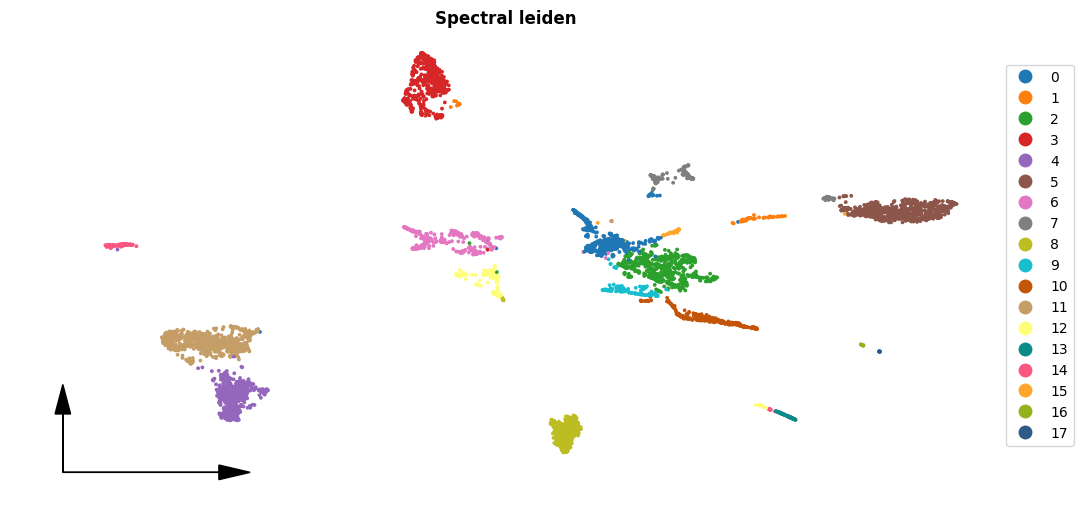

In [16]:
scit.gr.knn(adata,'X_spectral',n_neighbors=5)
g = scit.gr.neighbor_graph(adata)

# Run leiden and UMAP
scit.gr.leiden(adata, g, 0.5)
scit.em.umap(adata, 'X_spectral')
scit.pl.embedding2d(adata, 'X_umap', 'leiden', title='Spectral leiden')

In [17]:
adata.write_h5ad('private/data/marek/ATAC.h5ad')